# **Compounds Theoratical Aeff, ED & Zeff & Zeff_2.7**

In [2]:
# @title
!pip install xraylib
import pandas as pd
import numpy as np

NA = 6.02214076e23

# -------------------------------------------------
# ELEMENT DENSITIES (g/cm³)
# -------------------------------------------------
element_density = {
    1: 0.000084, 6: 2, 8: 0.001332, 11: 0.971, 12: 1.74,
    13: 2.6989, 14: 2.33, 16: 2.2, 17: 0.002995,
    19: 0.862, 20: 1.55, 26: 7.874, 27: 8.9, 28: 8.902,
}

# -------------------------------------------------
# ATOMIC WEIGHTS
# -------------------------------------------------
atomic_weights = {
    1: 1.008, 6: 12.011, 8: 15.999, 11: 22.990,
    12: 24.305, 13: 26.982, 14: 28.085, 15: 30.974,
    16: 32.06, 17: 35.45, 19: 39.098, 20: 40.078,
    26: 55.845, 27: 58.933, 28: 58.693,
}

# -------------------------------------------------
# helpers
# -------------------------------------------------
def parse_list(cell):
    return [float(x.strip()) for x in str(cell).split(",")]

# -------------------------------------------------
# Theoretical Density
# -------------------------------------------------
def compute_theoretical_density(Z, w):
    Z = np.array(Z)
    w = np.array(w)
    w = w / np.sum(w)

    rho = 1.0 / np.sum(
        w / np.array([element_density[int(z)] for z in Z])
    )
    return rho

# -------------------------------------------------
# Electron Density
# -------------------------------------------------
def compute_electron_density(density, Z, w):
    Z = np.array(Z)
    w = np.array(w)
    w = w / np.sum(w)

    A = np.array([atomic_weights[int(z)] for z in Z])

    ne = density * NA * np.sum(w * (Z / A))
    return ne

# -------------------------------------------------
# Zeff (p-power law)
# -------------------------------------------------
def calc_zeff(Z, w, p=2.7):
    Z = np.array(Z, dtype=float)
    w = np.array(w, dtype=float)
    w = w / np.sum(w)

    return (np.sum(w * (Z ** p))) ** (1 / p)

# ==========================================================
# READ INPUT
# ==========================================================
input_file = "Compounds.xlsx"
output_file = "Compounds_All_Properties.xlsx"

df = pd.read_excel(input_file)

# ==========================================================
# CALCULATE
# ==========================================================
theoretical_density = []
electron_density = []
Aeff_list = []
Zeff_list = []
Zeff_p27_list = []

for _, row in df.iterrows():

    density = float(row["Density_g_cm3"])
    Z = parse_list(row["Atomic Number"])
    w = parse_list(row["MassFractions"])

    # --- densities ---
    rho_theory = compute_theoretical_density(Z, w)
    ne = compute_electron_density(density, Z, w)

    # --- effective atomic mass ---
    w_norm = np.array(w) / np.sum(w)
    A = np.array([atomic_weights[int(z)] for z in Z])
    Aeff = np.sum(w_norm * A)

    # --- Zeff (your original method) ---
    Zeff = (ne * Aeff) / (NA * density)

    # --- Zeff (p=2.7) ---
    Zeff_p27 = calc_zeff(Z, w, p=2.7)

    theoretical_density.append(rho_theory)
    electron_density.append(ne)
    Aeff_list.append(Aeff)
    Zeff_list.append(Zeff)
    Zeff_p27_list.append(Zeff_p27)

# ==========================================================
# ADD COLUMNS
# ==========================================================
df["Theoretical Density (g/cm3)"] = theoretical_density
df["Electron Density (e/cm³)"] = electron_density
df["A_eff (g/mol)"] = Aeff_list
df["Z_eff"] = Zeff_list
df["Zeff (p=2.7)"] = Zeff_p27_list

# ==========================================================
# SAVE
# ==========================================================
df.to_excel(output_file, index=False)

print(df.head())
print("\nSaved to:", output_file)

     Compound    Elements Atomic Number  \
0       CaCO₃    C, O, Ca        6,8,20   
1  CaMg(CO₃)₂   C,O,Mg,Ca  6, 8, 12, 20   
2        SiO₂       O, Si          6,14   
3    KAlSi₃O₈   O,Al,Si,K    8,13,14,19   
4   NaAlSi₃O₈  O,Na,Al,Si    8,11,13,14   

                            MassFractions  Density_g_cm3  \
0                  0.1200, 0.4796, 0.4004           2.80   
1  0.130270, 0.520584, 0.131805, 0.217341           2.85   
2                          0.5326, 0.4674           2.32   
3     0.459866,0.096940,0.302720,0.140474           2.56   
4     0.488116,0.087673,0.102895,0.321316           2.62   

   Theoretical Density (g/cm3)  Electron Density (e/cm³)  A_eff (g/mol)  \
0                     0.002775              8.423753e+23      25.161672   
1                     0.002557              8.562982e+23      21.807610   
2                     2.141782              6.972394e+23      19.523988   
3                     0.002894              7.643894e+23      23.967175   
4    

# **Zeff - 1.0 < p < 4.0**

In [3]:
# @title
# ==========================================================
# Simplified Zeff calculator (loop over p values)
# ==========================================================

!pip install xraylib
import pandas as pd
import numpy as np

# ----------------------------------------------------------
# Zeff function
# ----------------------------------------------------------
def calc_zeff(Z, w, p):
    Z = np.array(Z, dtype=float)
    w = np.array(w, dtype=float)

    w = w / np.sum(w)

    return (np.sum(w * (Z ** p))) ** (1 / p)


# ----------------------------------------------------------
# parse helper
# ----------------------------------------------------------
def parse_list(cell):
    return [float(x.strip()) for x in str(cell).split(",")]


# ----------------------------------------------------------
# READ FILE
# ----------------------------------------------------------
input_file = "/content/drive/MyDrive/NIST Data Lables/Compounds.xlsx"
output_file = "Compounds_Zeff_results.xlsx"

df = pd.read_excel(input_file)

# p values
p_values = np.arange(1.0, 4.0, 0.1)

# ----------------------------------------------------------
# CALCULATE
# ----------------------------------------------------------
results = []

for _, row in df.iterrows():

    Z = parse_list(row["Atomic Number"])
    w = parse_list(row["MassFractions"])

    row_result = {
        "Compound": row["Compound"],
        "Elements": row["Elements"],
        "Atomic Number": row["Atomic Number"],
        "MassFractions": row["MassFractions"]
    }

    # compute all p automatically
    for p in p_values:
        row_result[f"Zeff (p={p})"] = calc_zeff(Z, w, p)

    results.append(row_result)


# ----------------------------------------------------------
# SAVE
# ----------------------------------------------------------
df_out = pd.DataFrame(results)

df_out.to_excel(output_file, index=False)

print("Saved to:", output_file)
print(df_out.head())

Saved to: Compounds_Zeff_results.xlsx
     Compound    Elements Atomic Number  \
0       CaCO₃    C, O, Ca        6,8,20   
1  CaMg(CO₃)₂   C,O,Mg,Ca  6, 8, 12, 20   
2        SiO₂       O, Si          6,14   
3    KAlSi₃O₈   O,Al,Si,K    8,13,14,19   
4   NaAlSi₃O₈  O,Na,Al,Si    8,11,13,14   

                            MassFractions  Zeff (p=1.0)  Zeff (p=1.1)  \
0                  0.1200, 0.4796, 0.4004     12.564800     12.710500   
1  0.130270, 0.520584, 0.131805, 0.217341     10.874772     10.981710   
2                          0.5326, 0.4674      9.739200      9.821640   
3     0.459866,0.096940,0.302720,0.140474     11.846234     11.910444   
4     0.488116,0.087673,0.102895,0.321316     10.705390     10.740904   

   Zeff (p=1.2000000000000002)  Zeff (p=1.3000000000000003)  \
0                    12.855786                    13.000355   
1                    11.090266                    11.200283   
2                     9.903529                     9.984743   
3           

# **Weighted Linear Attenuation Coefficient (wLAC)**

In [4]:
import numpy as np
import pandas as pd
# @title
def compute_weighted_lac(LAC_energies, LAC_values, spectrum_df, E_low, E_high):
    # Filter energies inside the bin
    window_df = spectrum_df[(spectrum_df['Energy'] >= E_low) & (spectrum_df['Energy'] <= E_high) ]
    energies = window_df['Energy'].values
    photons  = window_df['Photons'].values
    if len(energies) < 2:
      return None  # Not enough points to integrate

    LAC = np.interp(energies, LAC_energies, LAC_values)                     # LAC at All energy values
    h = np.diff(energies)                                                   # Energy spacing (for trapezoid)
    num = np.sum(h * (LAC[:-1] * photons[:-1] + LAC[1:] * photons[1:]) / 2) # Trapezoid numerator: ∫ µ(E)·Φ(E) dE
    den = np.sum(h * (photons[:-1] + photons[1:]) / 2)                      # Trapezoid denominator: ∫ Φ(E) dE
    weighted_LAC = num / den if den != 0 else None

    return weighted_LAC

# @title
def compute_weighted_lac_5bins(LAC_df, spectrum_df, thresholds):
    """
    thresholds = [E0, E1, E2, E3, E4, E5]
    defines 5 bins:
        bin1 = E0–E1
        bin2 = E1–E2
        bin3 = E2–E3
        bin4 = E3–E4
        bin5 = E4–E5
    """
    """
    LAC_df: DataFrame with columns ['Energy_keV', 'Material1', 'Material2', ...]
    spectrum_df: DataFrame with ['Energy','Photons']
    thresholds: list of bin edges, e.g., [0, 0.040, 0.050, 0.060, 0.080, 0.1140]
    """
    materials = LAC_df.columns[1:]  # skip 'Energy_MeV'
    LAC_energies = LAC_df['Energy_MeV'].values
    results = {}
    for mat in materials:
        LAC_values = LAC_df[mat].values
        mus = []  # store µ_eff for each bin
        for i in range(len(thresholds) - 1):
          E_low  = thresholds[i]
          E_high = thresholds[i+1]
          mu_eff = compute_weighted_lac(LAC_energies, LAC_values, spectrum_df, E_low, E_high)
          mus.append(mu_eff)
          results[mat] = mus
    return results

In [5]:
# @title
thresholds = [0, 0.040, 0.050, 0.060, 0.080, 0.1140]  # 5-bin system → 6 threshold edges
LAC_df = pd.read_excel("/content/drive/MyDrive/NIST Data Lables/C_LAC_df.xlsx")  # Columns: Energy_keV, LAC
spectrum_df = pd.read_excel("/content/drive/MyDrive/NIST Data Lables/spectrum_df.xlsx")  # Columns: Energy, Photons
weighted_LAC = compute_weighted_lac_5bins(LAC_df, spectrum_df, thresholds)

for mat, mus in weighted_LAC.items():
    print(f"{mat}: {mus}")

# Convert dictionary → DataFrame (proper orientation)
weighted_LAC_df = pd.DataFrame.from_dict(
    weighted_LAC,
    orient="index",
    columns=["wLAC_1", "wLAC_2", "wLAC_3", "wLAC_4", "wLAC_5"]
)

# Move index to column
weighted_LAC_df.reset_index(inplace=True)

# Rename first column
weighted_LAC_df.rename(columns={"index": "Compound"}, inplace=True)

# Save to Excel
output_file = "Compounds_Weighted_LAC_5bins.xlsx"
weighted_LAC_df.to_excel(output_file, index=False)

print(weighted_LAC_df.head())
print(f"\nSaved to: {output_file}")

CaCO₃: [np.float64(3.9527316526335357), np.float64(1.899157663449817), np.float64(1.22353854507724), np.float64(0.8662101962210079), np.float64(0.6016597429382913)]
CaMg(CO₃)₂: [np.float64(2.742623470567494), np.float64(1.40652881103753), np.float64(0.9646343410287952), np.float64(0.7278320112762059), np.float64(0.5472356084833696)]
SiO₂: [np.float64(1.599715454426873), np.float64(0.8810494333352142), np.float64(0.6441211257358016), np.float64(0.5153258770519195), np.float64(0.4132886383513645)]
KAlSi₃O₈: [np.float64(2.38032029369513), np.float64(1.222800232452907), np.float64(0.8427689991804723), np.float64(0.6395772860948986), np.float64(0.484455421353169)]
NaAlSi₃O₈: [np.float64(1.7139541289192493), np.float64(0.9555528711458858), np.float64(0.7051194285563421), np.float64(0.5685037594213463), np.float64(0.4595209117706919)]
CaAl₂Si₂O₈: [np.float64(2.7067324683487533), np.float64(1.3764379014964965), np.float64(0.9392074221876869), np.float64(0.7057713713825085), np.float64(0.528421

# **Inverse Calibration Parameters**

**Uncalibarted QRM Image & NIST XCOM**

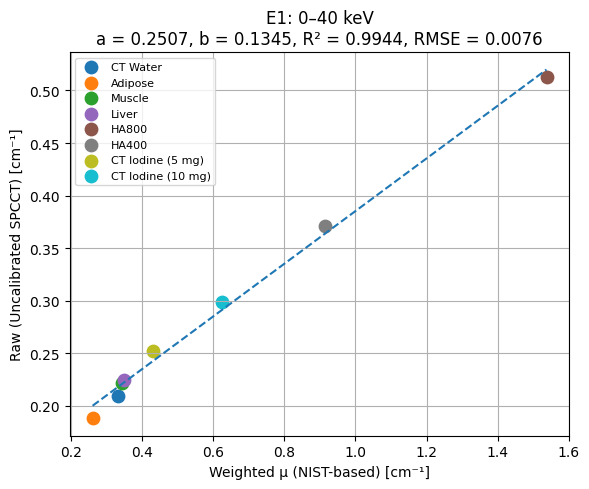

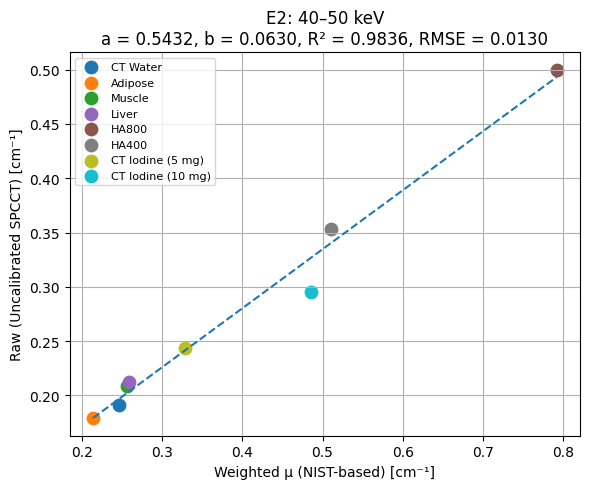

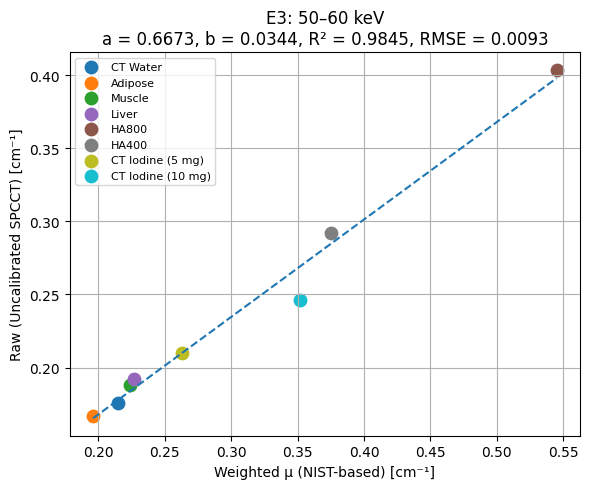

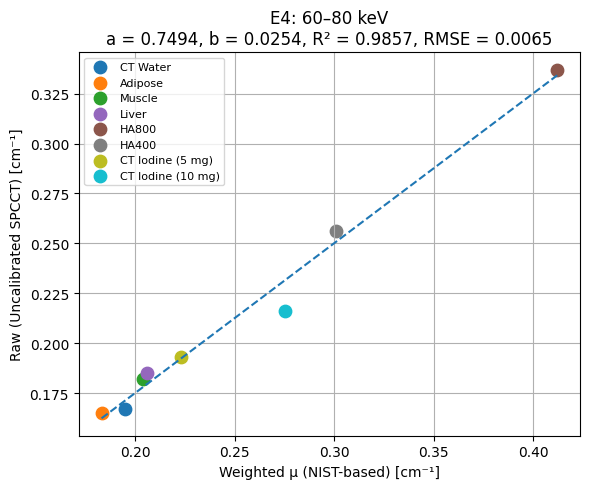

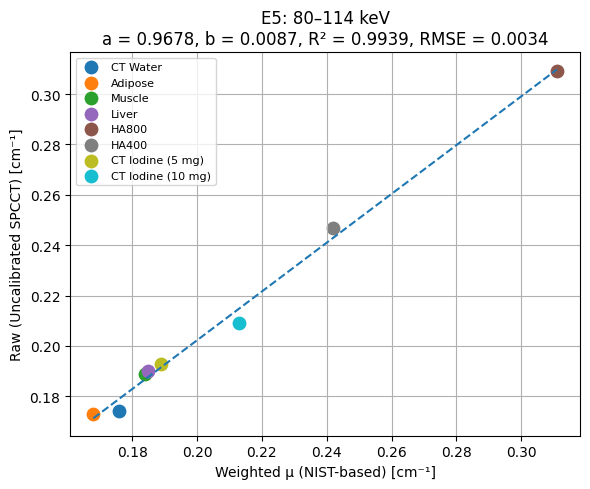


Calibration Parameters from NIST XCOM vs Uncalubrated QRM:
Bin 0: a=0.2507, b=0.1345, R²=0.9944
Bin 1: a=0.5432, b=0.0630, R²=0.9836
Bin 2: a=0.6673, b=0.0344, R²=0.9845
Bin 3: a=0.7494, b=0.0254, R²=0.9857
Bin 4: a=0.9678, b=0.0087, R²=0.9939


In [7]:
# @title
# Uncalibarted QRM Image & NIST XCOM

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# --------------------------------------------------
# MATERIALS
# --------------------------------------------------
materials = [
    "CT Water", "Adipose", "Muscle", "Liver",
    "HA800", "HA400", "CT Iodine (5 mg)", "CT Iodine (10 mg)"
]

# --------------------------------------------------
# ENERGY BINS
# --------------------------------------------------
energy_bins = [
    "E1: 0–40 keV",
    "E2: 40–50 keV",
    "E3: 50–60 keV",
    "E4: 60–80 keV",
    "E5: 80–114 keV"
]

# --------------------------------------------------
# DATA (FROM YOUR TABLE)
# --------------------------------------------------

# μ (NIST-based weighted LAC)
mu = np.array([
    [0.332, 0.246, 0.215, 0.195, 0.176],
    [0.261, 0.214, 0.196, 0.183, 0.168],
    [0.343, 0.256, 0.224, 0.204, 0.184],
    [0.349, 0.259, 0.227, 0.206, 0.185],
    [1.537, 0.792, 0.545, 0.412, 0.311],
    [0.914, 0.510, 0.375, 0.301, 0.242],
    [0.432, 0.329, 0.263, 0.223, 0.189],
    [0.626, 0.485, 0.352, 0.275, 0.213],
])

# Raw (uncalibrated SPCCT)
R = np.array([
    [0.209, 0.191, 0.176, 0.167, 0.174],
    [0.188, 0.179, 0.167, 0.165, 0.173],
    [0.222, 0.209, 0.188, 0.182, 0.189],
    [0.224, 0.212, 0.192, 0.185, 0.190],
    [0.513, 0.500, 0.404, 0.337, 0.309],
    [0.371, 0.353, 0.292, 0.256, 0.247],
    [0.252, 0.244, 0.210, 0.193, 0.193],
    [0.299, 0.295, 0.246, 0.216, 0.209],
])

# --------------------------------------------------
# COLORS
# --------------------------------------------------
colors = plt.cm.tab10(np.linspace(0, 1, len(materials)))

# --------------------------------------------------
# CALIBRATION + PLOTTING
# --------------------------------------------------

calibration_params = {}

for i, energy in enumerate(energy_bins):

    mu_vals = mu[:, i]
    R_vals = R[:, i]

    # Fit linear model
    model = LinearRegression()
    model.fit(mu_vals.reshape(-1, 1), R_vals)

    a = model.coef_[0]
    b = model.intercept_

    R_pred = model.predict(mu_vals.reshape(-1, 1))

    # Metrics
    r2 = r2_score(R_vals, R_pred)
    rmse = np.sqrt(mean_squared_error(R_vals, R_pred))

    calibration_params[i] = {"a": a, "b": b, "r2": r2}

    # --------------------------------------------------
    # PLOT
    # --------------------------------------------------

    plt.figure(figsize=(6,5))

    # Scatter per material
    for j, material in enumerate(materials):
        plt.scatter(
            mu_vals[j],
            R_vals[j],
            color=colors[j],
            label=material,
            s=80
        )

    # Fitted line (IMPORTANT: NOT y=x)
    x_line = np.linspace(mu_vals.min(), mu_vals.max(), 100)
    y_line = a * x_line + b
    plt.plot(x_line, y_line, linestyle='--')

    # Labels
    plt.xlabel("Weighted μ (NIST-based) [cm⁻¹]")
    plt.ylabel("Raw (Uncalibrated SPCCT) [cm⁻¹]")

    plt.title(
        f"{energy}\n"
        f"a = {a:.4f}, b = {b:.4f}, R² = {r2:.4f}, RMSE = {rmse:.4f}"
    )

    plt.grid(True)
    plt.legend(fontsize=8, loc='best')

    plt.tight_layout()
    plt.show()

# --------------------------------------------------
# PRINT FINAL PARAMETERS
# --------------------------------------------------

print("\nCalibration Parameters from NIST XCOM vs Uncalubrated QRM:")
for k, v in calibration_params.items():
    print(f"Bin {k}: a={v['a']:.4f}, b={v['b']:.4f}, R²={v['r2']:.4f}")

# **Inverse Calibration to wLAC**

In [8]:
# @title
import numpy as np
import pandas as pd

# -------------------------------------------------
# Calibration parameters
# -------------------------------------------------
calibration_params = {
    1: {"a": 0.2507, "b": 0.1345},
    2: {"a": 0.5432, "b": 0.0630},
    3: {"a": 0.6673, "b": 0.0344},
    4: {"a": 0.7494, "b": 0.0254},
    5: {"a": 0.9678, "b": 0.0087},
}

# -------------------------------------------------
# READ wLAC FROM EXCEL
# -------------------------------------------------
input_file = "Compounds_Weighted_LAC_5bins.xlsx"
output_file = "Compounds_Inverse_Calibrated_wLAC.xlsx"

df_wlac = pd.read_excel(input_file)

# -------------------------------------------------
# CONVERT TO DICTIONARY FORMAT
# -------------------------------------------------
wLAC = {}

for _, row in df_wlac.iterrows():
    compound = row["Compound"]
    wLAC[compound] = [
        row["wLAC_1"],
        row["wLAC_2"],
        row["wLAC_3"],
        row["wLAC_4"],
        row["wLAC_5"],
    ]

# -------------------------------------------------
# APPLY CALIBRATION
# -------------------------------------------------
calibrated = {}

for mat, vals in wLAC.items():
    calibrated[mat] = [
        calibration_params[i + 1]["a"] * v + calibration_params[i + 1]["b"]
        for i, v in enumerate(vals)
    ]

# -------------------------------------------------
# CREATE DATAFRAME
# -------------------------------------------------
df = pd.DataFrame.from_dict(calibrated, orient="index")
df.columns = ["wLAC_1","wLAC_2","wLAC_3","wLAC_4","wLAC_5"]

df.index.name = "Compound"
df.reset_index(inplace=True)

# -------------------------------------------------
# SAVE TO EXCEL
# -------------------------------------------------
df.to_excel(output_file, index=False)

print(df)
print(f"\nSaved to: {output_file}")

          Compound    wLAC_1    wLAC_2    wLAC_3    wLAC_4    wLAC_5
0            CaCO₃  1.125450  1.094622  0.850867  0.674538  0.590986
1       CaMg(CO₃)₂  0.822076  0.827026  0.678100  0.570837  0.538315
2             SiO₂  0.535549  0.541586  0.464222  0.411585  0.408681
3         KAlSi₃O₈  0.731246  0.727225  0.596780  0.504699  0.477556
4        NaAlSi₃O₈  0.564188  0.582056  0.504926  0.451437  0.453424
5       CaAl₂Si₂O₈  0.813078  0.810681  0.661133  0.554305  0.520106
6          Fe₂SiO₄  4.109717  3.886556  2.769719  1.938344  1.401203
7          Mg₂SiO₄  0.643637  0.687642  0.607227  0.548926  0.560340
8    Mg₃Si₂O₅(OH)₄  0.511868  0.535011  0.473232  0.430843  0.440414
9   Mg₃Si₄O₁₀(OH)₂  0.563805  0.587596  0.514030  0.462713  0.468332
10           Fe₂O₃  5.847306  5.504271  3.875855  2.661293  1.856957
11           Fe₃O₄  5.996009  5.637296  3.961860  2.712569  1.882066
12         FeO(OH)  4.375603  4.126275  2.924260  2.029081  1.442855
13           FeCO₃  3.457614  3.29

# **K Values from Uncalibrated 792.dcm**

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 37.1 MB/s eta 0:00:00
Loaded DICOM shape: (5, 1280, 1280)


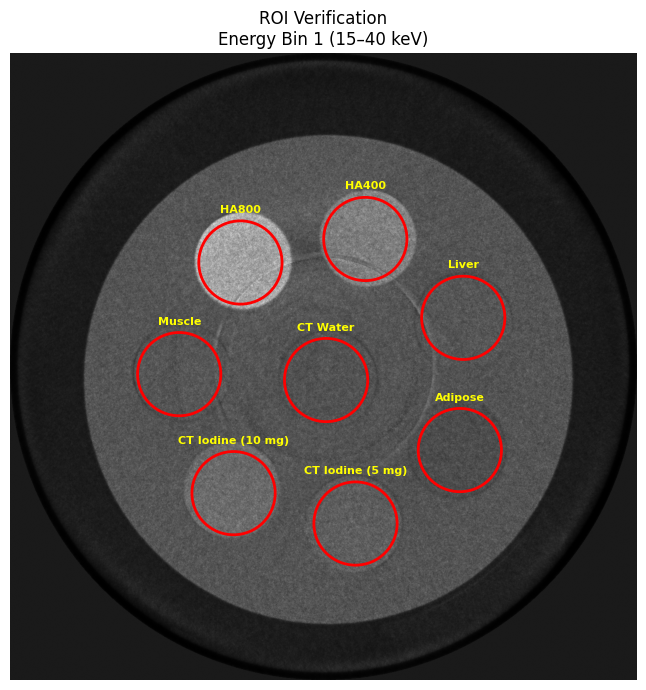

✔ CV analysis saved to Excel


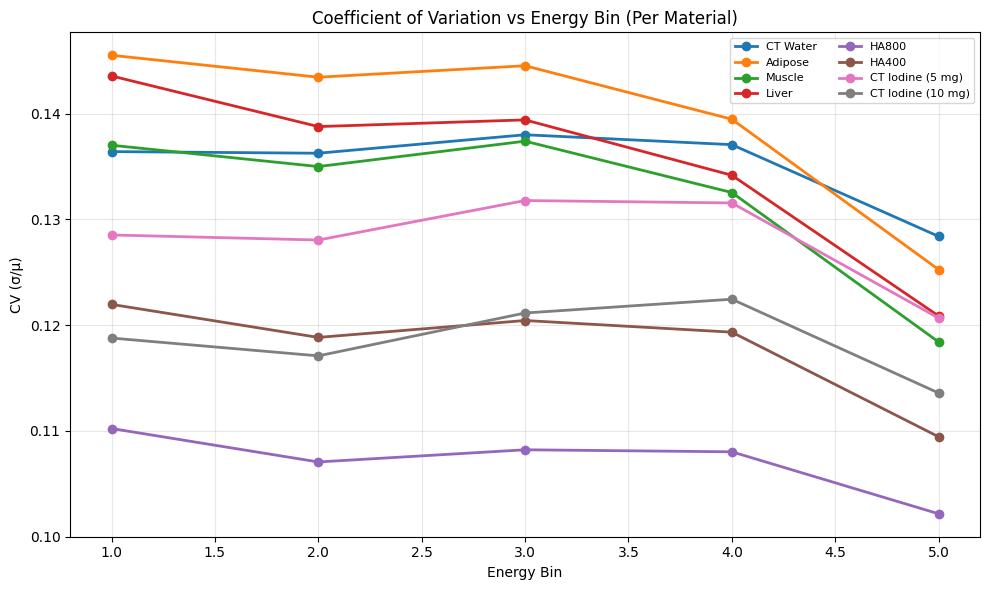

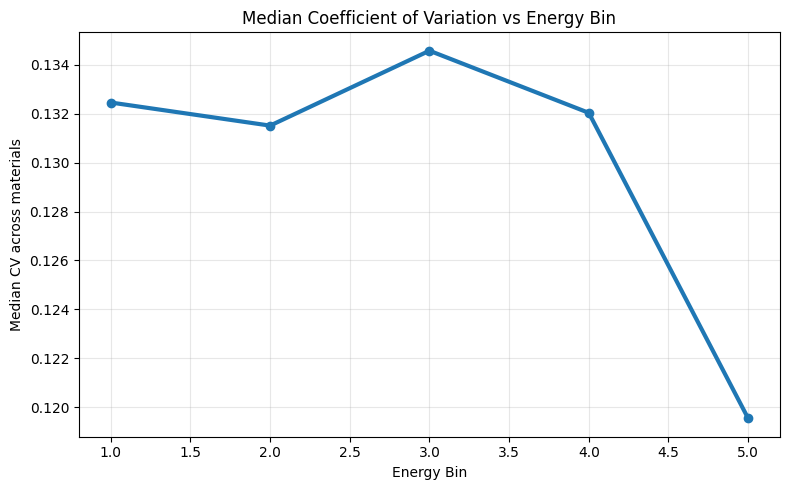

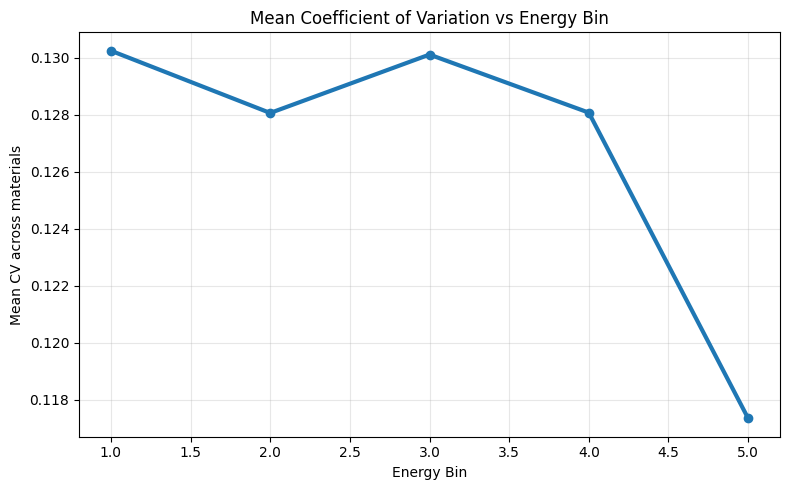

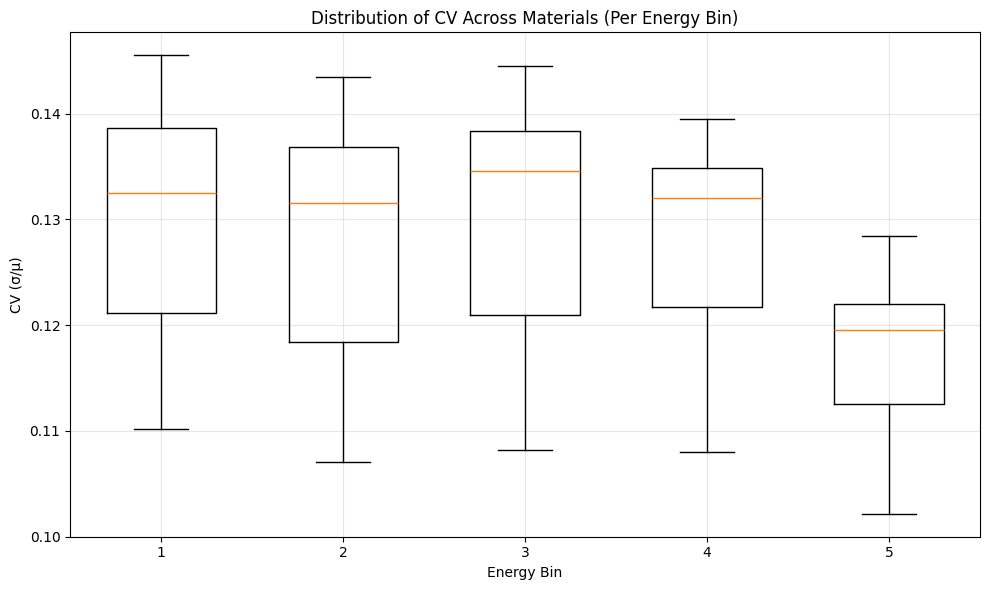

   Energy Bin Energy Range  Median_CV   Mean_CV    Std_CV
0           1    15–40 keV   0.132462  0.130245  0.012521
1           2    40–50 keV   0.131517  0.128060  0.012604
2           3    50–60 keV   0.134582  0.130110  0.012335
3           4    60–80 keV   0.132039  0.128072  0.010619
4           5   80–114 keV   0.119537  0.117346  0.008585


In [9]:
# @title
!pip install xlsxwriter
!pip install pydicom

# ============================================================
# SPCCT QRM Phantom — CV Analysis
# Single Multi-frame DICOM with 5 Energy Bins
# ============================================================

import numpy as np
import pandas as pd
import pydicom
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ------------------------------------------------------------
# USER INPUTS
# ------------------------------------------------------------

DICOM_FILE = "/content/drive/MyDrive/NIST Data Lables/792 Uncalibrated - final.dcm"
OUTPUT_EXCEL = "QRM_CV_results.xlsx"

ENERGY_BINS_LABELS = [
    "15–40 keV",
    "40–50 keV",
    "50–60 keV",
    "60–80 keV",
    "80–114 keV",
]

ROI_RADIUS = 85  # pixels

MATERIAL_CENTERS = {
    "CT Water": (645, 667),
    "Adipose": (918, 810),
    "Muscle": (345, 655),
    "Liver": (925, 540),
    "HA800": (470, 427),
    "HA400": (725, 379),
    "CT Iodine (5 mg)": (705, 960),
    "CT Iodine (10 mg)": (456, 898)
}

# ------------------------------------------------------------
# FUNCTIONS
# ------------------------------------------------------------

def circular_roi_mask(shape, center_xy, radius):
    cx, cy = center_xy
    yy, xx = np.ogrid[:shape[0], :shape[1]]
    return (xx - cx)**2 + (yy - cy)**2 <= radius**2

# ------------------------------------------------------------
# LOAD MULTI-FRAME DICOM
# ------------------------------------------------------------

ds = pydicom.dcmread(DICOM_FILE)
img_stack = ds.pixel_array.astype(np.float32)

# Apply rescale if present
slope = getattr(ds, "RescaleSlope", 1)
intercept = getattr(ds, "RescaleIntercept", 0)
img_stack = img_stack * slope + intercept

print("Loaded DICOM shape:", img_stack.shape)

# Expecting shape (5, H, W)
assert img_stack.shape[0] == 5, "DICOM must contain 5 energy bins."

# ------------------------------------------------------------
# ROI VISUALIZATION
# ------------------------------------------------------------

BIN_TO_SHOW = 0
img = img_stack[BIN_TO_SHOW]

plt.figure(figsize=(7, 7))
plt.imshow(img, cmap="gray")
plt.title(f"ROI Verification\nEnergy Bin {BIN_TO_SHOW+1} ({ENERGY_BINS_LABELS[BIN_TO_SHOW]})")
plt.axis("off")

ax = plt.gca()

for material, (cx, cy) in MATERIAL_CENTERS.items():
    circle = patches.Circle((cx, cy), ROI_RADIUS,
                            fill=False, edgecolor="red", linewidth=2)
    ax.add_patch(circle)

    ax.text(cx, cy - ROI_RADIUS - 12,
            material, color="yellow", fontsize=8,
            ha="center", va="bottom", weight="bold")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# COMPUTE CV (σ / μ)
# ------------------------------------------------------------

records = []

for b in range(5):

    img = img_stack[b]

    for material, center in MATERIAL_CENTERS.items():

        mask = circular_roi_mask(img.shape, center, ROI_RADIUS)
        roi_pixels = img[mask]

        mu_hat = np.mean(roi_pixels)
        sigma_hat = np.std(roi_pixels, ddof=1)

        if mu_hat != 0:
            cv_val = sigma_hat / mu_hat
        else:
            cv_val = np.nan

        records.append({
            "Material": material,
            "Energy Bin": b + 1,
            "Energy Range": ENERGY_BINS_LABELS[b],
            "Mean (μ)": mu_hat,
            "Std Dev (σ)": sigma_hat,
            "CV (σ/μ)": cv_val
        })

cv_df = pd.DataFrame(records)

# ------------------------------------------------------------
# MAIN CV PER BIN
# ------------------------------------------------------------

main_cv_df = (
    cv_df
    .groupby(["Energy Bin", "Energy Range"])
    .agg(
        Median_CV=("CV (σ/μ)", "median"),
        Mean_CV=("CV (σ/μ)", "mean"),
        Std_CV=("CV (σ/μ)", "std")
    )
    .reset_index()
)

# ------------------------------------------------------------
# SAVE RESULTS
# ------------------------------------------------------------

with pd.ExcelWriter(OUTPUT_EXCEL, engine="xlsxwriter") as writer:
    cv_df.to_excel(writer, sheet_name="CV_per_material", index=False)
    main_cv_df.to_excel(writer, sheet_name="CV_per_bin", index=False)

print("✔ CV analysis saved to Excel")

# ------------------------------------------------------------
# PLOTS
# ------------------------------------------------------------

# Plot 1: Per material
plt.figure(figsize=(10, 6))
for material in cv_df["Material"].unique():
    subset = cv_df[cv_df["Material"] == material]
    plt.plot(subset["Energy Bin"],
             subset["CV (σ/μ)"],
             marker="o",
             linewidth=2,
             label=material)

plt.xlabel("Energy Bin")
plt.ylabel("CV (σ/μ)")
plt.title("Coefficient of Variation vs Energy Bin (Per Material)")
plt.legend(fontsize=8, ncol=2)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 2: Median CV
plt.figure(figsize=(8, 5))
plt.plot(main_cv_df["Energy Bin"],
         main_cv_df["Median_CV"],
         marker="o",
         linewidth=3)

plt.xlabel("Energy Bin")
plt.ylabel("Median CV across materials")
plt.title("Median Coefficient of Variation vs Energy Bin")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Plot: Mean CV
plt.figure(figsize=(8, 5))
plt.plot(main_cv_df["Energy Bin"],
         main_cv_df["Mean_CV"],
         marker="o",
         linewidth=3)

plt.xlabel("Energy Bin")
plt.ylabel("Mean CV across materials")
plt.title("Mean Coefficient of Variation vs Energy Bin")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 3: Distribution
plt.figure(figsize=(10, 6))
for b in sorted(cv_df["Energy Bin"].unique()):
    subset = cv_df[cv_df["Energy Bin"] == b]
    plt.boxplot(subset["CV (σ/μ)"],
                positions=[b],
                widths=0.6,
                showfliers=True)

plt.xlabel("Energy Bin")
plt.ylabel("CV (σ/μ)")
plt.title("Distribution of CV Across Materials (Per Energy Bin)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(main_cv_df)

Result: Scaling Factor k_bins = [0.130, 0.128, 0.130, 0.128, 0.117]

# **GD Parameter STD from σ=k⋅μ**

In [ ]:
import pandas as pd
import numpy as np

# -------------------------------------------------
# INPUT
# -------------------------------------------------
WLAC_FILE = "Compounds_Inverse_Calibrated_wLAC.xlsx"
OUTPUT_FILE = "Compounds WLAC_with_STD.xlsx"

# k values (per energy bin)
k_bins = np.array([0.130, 0.128, 0.130, 0.128, 0.117])

# μ column names in Excel
mu_cols = ["wLAC_1", "wLAC_2", "wLAC_3", "wLAC_4", "wLAC_5"]
wlac_df = pd.read_excel(WLAC_FILE)

# Extract μ values as numpy array
mu_values = wlac_df[mu_cols].values  # shape: (N, 5)
sigma_values = mu_values * k_bins  # CALCULATE σ = k * μ
sigma_cols = ["STD_1", "STD_2", "STD_3", "STD_4", "STD_5"]

for i in range(5):
    wlac_df[sigma_cols[i]] = sigma_values[:, i]
wlac_df.to_excel(OUTPUT_FILE, index=False)

print("\n=== Standard Deviation (σ = k * μ) ===\n")
print(wlac_df[["Compound"] + sigma_cols])

print(f"\n✅ Saved to: {OUTPUT_FILE}")


=== Standard Deviation (σ = k * μ) ===

          Compound     STD_1     STD_2     STD_3     STD_4     STD_5
0            CaCO₃  0.146308  0.140112  0.110613  0.086341  0.069145
1       CaMg(CO₃)₂  0.106870  0.105859  0.088153  0.073067  0.062983
2             SiO₂  0.069621  0.069323  0.060349  0.052683  0.047816
3         KAlSi₃O₈  0.095062  0.093085  0.077581  0.064601  0.055874
4        NaAlSi₃O₈  0.073344  0.074503  0.065640  0.057784  0.053051
5       CaAl₂Si₂O₈  0.105700  0.103767  0.085947  0.070951  0.060852
6          Fe₂SiO₄  0.534263  0.497479  0.360063  0.248108  0.163941
7          Mg₂SiO₄  0.083673  0.088018  0.078940  0.070263  0.065560
8    Mg₃Si₂O₅(OH)₄  0.066543  0.068481  0.061520  0.055148  0.051528
9   Mg₃Si₄O₁₀(OH)₂  0.073295  0.075212  0.066824  0.059227  0.054795
10           Fe₂O₃  0.760150  0.704547  0.503861  0.340645  0.217264
11           Fe₃O₄  0.779481  0.721574  0.515042  0.347209  0.220202
12         FeO(OH)  0.568828  0.528163  0.380154  0.259722  0.